In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score



In [61]:
insurance = pd.read_csv("insurance.csv")

In [62]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [63]:
X = insurance.drop(columns = ['charges'])
y = insurance['charges'] 

In [64]:
X['sex'] = X['sex'].map({'female':0, 'male':1})
X['smoker'] = X['smoker'].map({'yes':1, 'no':0})
X['age_smoker'] = X['age'] * X['smoker']
X['bmi_smoker'] = X['bmi'] * X['smoker']
X = pd.get_dummies(X, columns = ['region'], drop_first = True, dtype = int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)



MSE for alph 0.001 :  20922599.866357442
MSE for alph 0.1 :  20921803.10441334
MSE for alph 1 :  20914826.17625127
MSE for alph 2 :  20908102.559395272
MSE for alph 5 :  20890879.425717283
MSE for alph 10 :  20872843.41780807
MSE for alph 20 :  20877825.937621552
MSE for alph 30 :  20937533.172447264
MSE for alph 40 :  21046483.759861797
MSE for alph 50 :  21196922.06208091
MSE for alph 100 :  22423169.21193352


<Axes: >

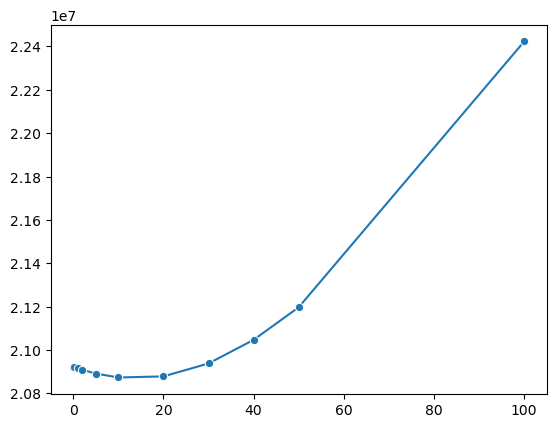

In [65]:
alphas = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]

mses = []

for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(X_train, y_train)
    
    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"MSE for alph {a} : ", mse)
    mses.append(mse)

sns.lineplot(x=alphas, y=mses, marker="o")

In [69]:
from sklearn.linear_model import LassoCV

a = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]

lasso_cv_model = LassoCV(
    alphas = a,
    cv = 5,
    max_iter=1000,
    random_state = 42   
)

lasso_cv_model = lasso_cv_model.fit(X_train, y_train)

print("Best Alphas : ", lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("r2 Score is : ", r2)

Best Alphas :  0.001
MSE : 20922599.866357442
r2 Score is :  0.8652317499453056


In [ ]:
# this is how we improve our model and get the accuracy 